# Notebook 14 – EDA Mini Challenge

This notebook performs an independent Exploratory Data Analysis on the Telco Customer Churn dataset.



# 1. Load the Dataset

The dataset used for this challenge is the IBM Telco Customer Churn dataset.

It contains customer demographic information, services, account information, billing information, and a Churn variable indicating whether the customer left the company.

The dataset contains 7,043 customer records and 21 columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/IBM/watsonx-ai-samples/master/cpd4.8/data/customer_churn/WA_FnUseC_TelcoCustomerChurn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")

df.head()

Dataset loaded successfully.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Understand the Dataset

The dataset represents customers of a telecommunications company.

Each row represents one customer.

The columns contain information about:

- Customer demographics
- Services used
- Contract information
- Payment methods
- Monthly charges
- Total charges
- Customer churn

The `Churn` column represents whether a customer left the company.

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows: 7043
Columns: 21

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


# 3. Inspect the Structure

The structure of the dataset is inspected to understand the number of observations, features, and the general format of the data.

In [3]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Last 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

# 4. Identify Data Types

Different columns contain different types of information.

Numerical variables can be used for mathematical analysis, while categorical variables represent groups or categories.

The data types need to be inspected before further analysis.

In [4]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


### Observation

The dataset contains both numerical and categorical variables.

Variables such as `tenure`, `MonthlyCharges`, and `SeniorCitizen` are numerical.

Variables such as `gender`, `Contract`, `InternetService`, and `PaymentMethod` are categorical.

`customerID` is an identifier rather than a meaningful analytical feature.

# 5. Identify Missing Values

Missing values are checked because incomplete information can affect statistical analysis and future machine learning models.

In [6]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
Series([], dtype: int64)


### Observation

The initial missing-value check should be interpreted together with the data types.

The `TotalCharges` column is stored as an object in the raw dataset, so blank values may not initially appear as standard missing values.

This is an important data-quality issue to investigate before preprocessing.

# 6. Identify Duplicates

Duplicate rows are checked to determine whether the same customer record appears more than once.

Duplicate observations can affect statistical analysis and model training.

In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Observation

The dataset contains no complete duplicate rows.

However, the `customerID` column should also be examined because it identifies individual customers.

# 7. Analyze Numerical Features

Numerical features are analyzed using descriptive statistics.

This helps us understand:

- Average values
- Minimum and maximum values
- Spread
- Quartiles
- Possible unusual values

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Observation

The numerical variables have different scales.

`tenure` represents the number of months a customer has stayed with the company.

`MonthlyCharges` represents the customer's monthly bill.

`SeniorCitizen` is a binary numerical variable indicating whether the customer is a senior citizen.

The numerical ranges should be considered during future preprocessing and modeling.

# 8. Analyze Categorical Features

Categorical features are analyzed by examining their unique values and frequencies.

This helps identify the main customer segments represented in the dataset.

In [9]:
for column in categorical_features:
    print(f"\n{column}")
    print(df[column].value_counts().head(10))


customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
7398-LXGYX    1
1035-IPQPU    1
7203-OYKCT    1
1699-HPSBG    1
9837-FWLCH    1
Name: count, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Na

### Observation

The dataset contains many categorical variables describing customer demographics, services, contracts, and payment methods.

These variables can be useful for identifying customer segments with different churn behavior.

# 9. Analyze Customer Churn

The `Churn` column is the main outcome variable.

Understanding its distribution is important because it tells us how many customers stayed and how many customers left.

In [10]:
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


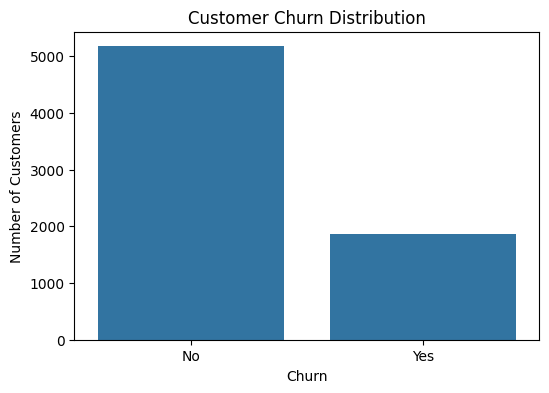

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The dataset contains both customers who stayed and customers who churned.

The classes are not evenly distributed, with customers who stayed representing the larger group.

This class distribution should be considered during future machine learning modeling.

# 10. Detect Outliers

Outliers are observations that are unusually far from the rest of the data.

The IQR method will be used to identify potential outliers in the numerical features.

In [12]:
outlier_summary = {}

for column in ["tenure", "MonthlyCharges"]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

print("Potential outliers:")
print(outlier_summary)

Potential outliers:
{'tenure': 0, 'MonthlyCharges': 0}


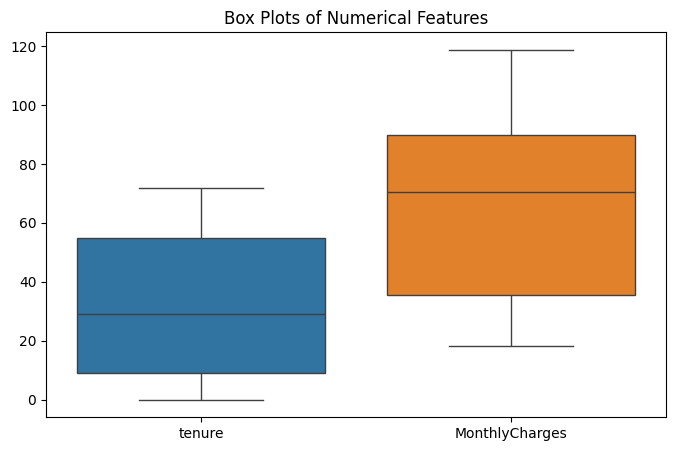

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df[["tenure", "MonthlyCharges"]])

plt.title("Box Plots of Numerical Features")

plt.show()

### Observation

The box plots help identify unusually high or low values in the numerical features.

Potential outliers should not automatically be removed.

They need to be investigated to determine whether they represent genuine customers or incorrect data.

# 11. Analyze Distributions

Distributions are examined to understand how numerical variables are spread.

Histograms are used for `tenure`, `MonthlyCharges`, and `TotalCharges`.

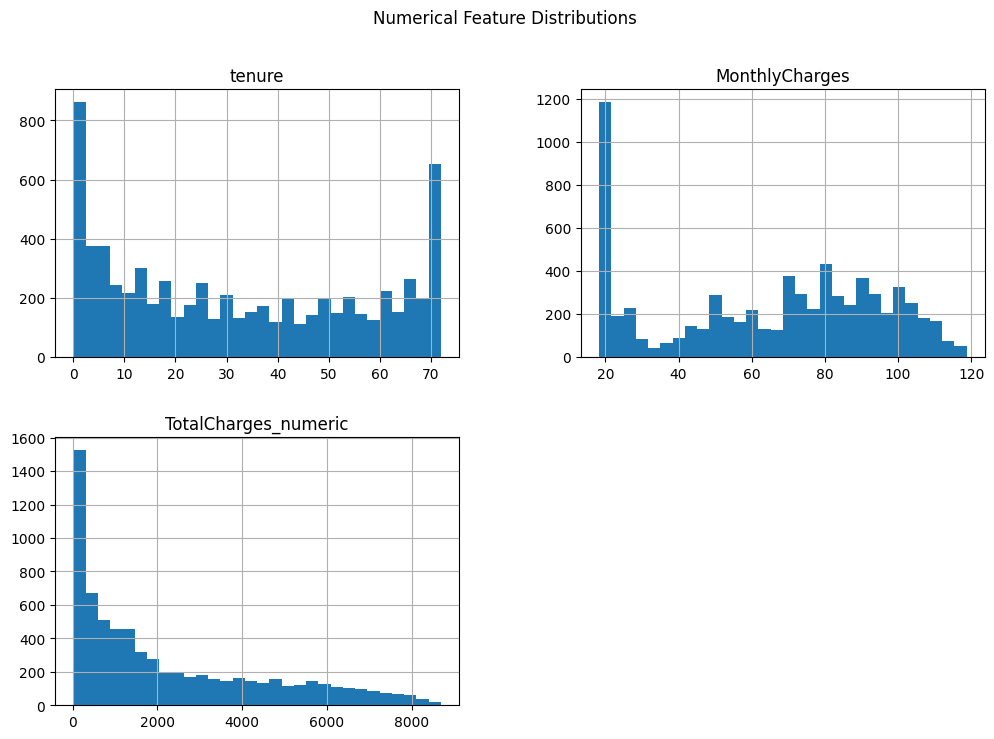

In [14]:
df["TotalCharges_numeric"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

numeric_distribution_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges_numeric"
]

df[numeric_distribution_columns].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Numerical Feature Distributions")

plt.show()

### Observation

The distributions show that the numerical variables do not all follow the same shape.

`tenure` contains many customers with relatively short and long periods of service.

`MonthlyCharges` shows variation in monthly billing amounts.

`TotalCharges` is strongly related to how long customers have stayed and the amount they pay.

# 12. Analyze Correlations

Correlation is used to understand relationships between numerical variables.

A correlation close to +1 indicates a strong positive relationship.

A correlation close to -1 indicates a strong negative relationship.

A correlation close to 0 indicates a weak linear relationship.

In [15]:
correlation = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges_numeric"]
].corr()

print(correlation)

                      SeniorCitizen    tenure  MonthlyCharges  \
SeniorCitizen              1.000000  0.016567        0.220173   
tenure                     0.016567  1.000000        0.247900   
MonthlyCharges             0.220173  0.247900        1.000000   
TotalCharges_numeric       0.102411  0.825880        0.651065   

                      TotalCharges_numeric  
SeniorCitizen                     0.102411  
tenure                            0.825880  
MonthlyCharges                    0.651065  
TotalCharges_numeric              1.000000  


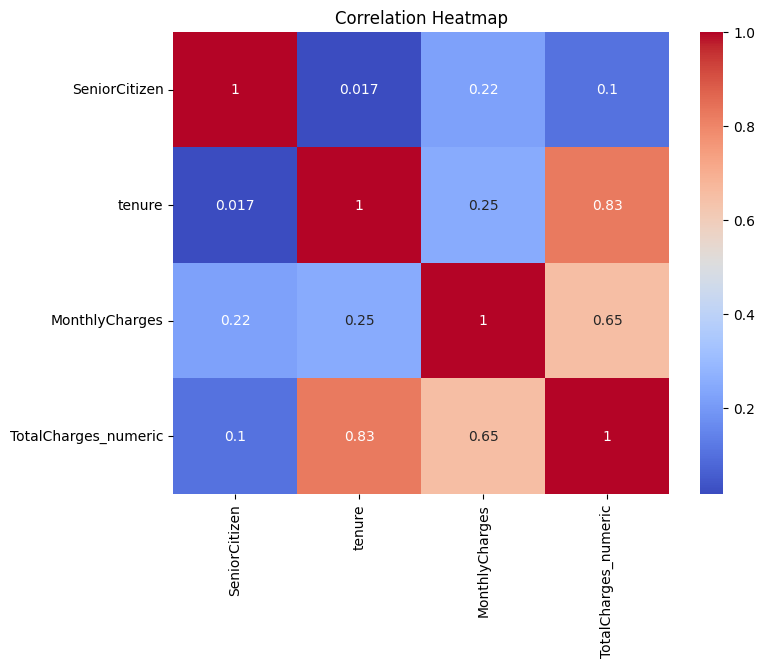

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The strongest relationship is expected between `tenure` and `TotalCharges`.

Customers who stay longer generally accumulate higher total charges.

`MonthlyCharges` is also related to `TotalCharges` because customers with higher monthly bills can accumulate larger total charges over time.

# 13. Meaningful Visualizations

The following visualizations are used to investigate important customer patterns:

- Churn by Contract
- Churn by Internet Service
- Monthly Charges by Churn
- Tenure by Churn
- Churn by Payment Method

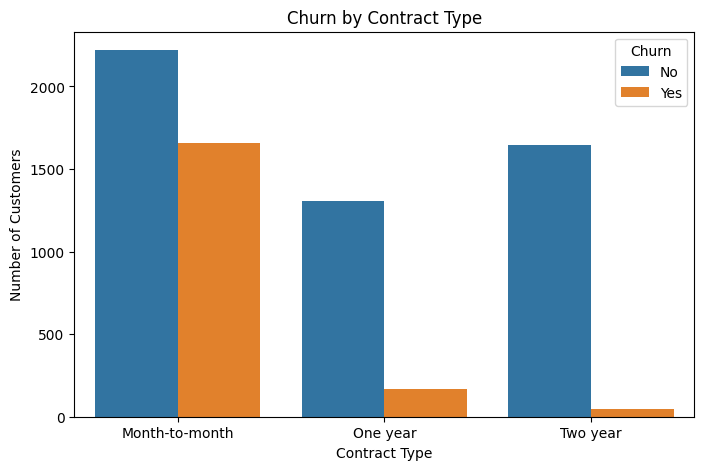

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Customers with month-to-month contracts show substantially more churn than customers with longer-term contracts.

### Insight

Contract type appears to be an important factor associated with customer retention.

Customers without long-term commitments may be easier to lose.

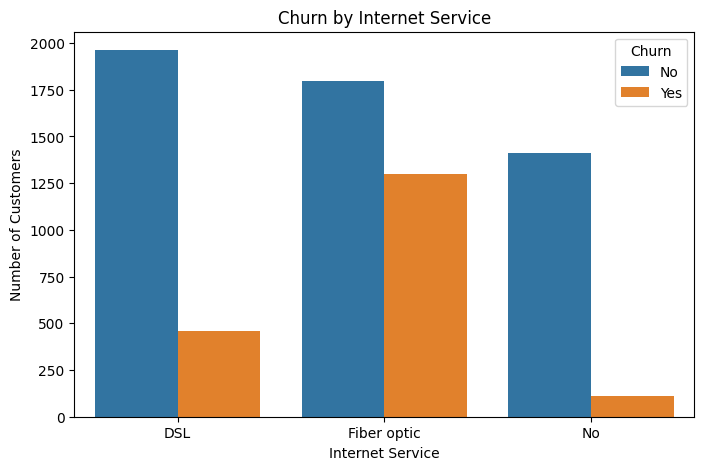

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Churn levels differ between internet service categories.

### Insight

Internet service type may be associated with customer churn and should be investigated further during business analysis.

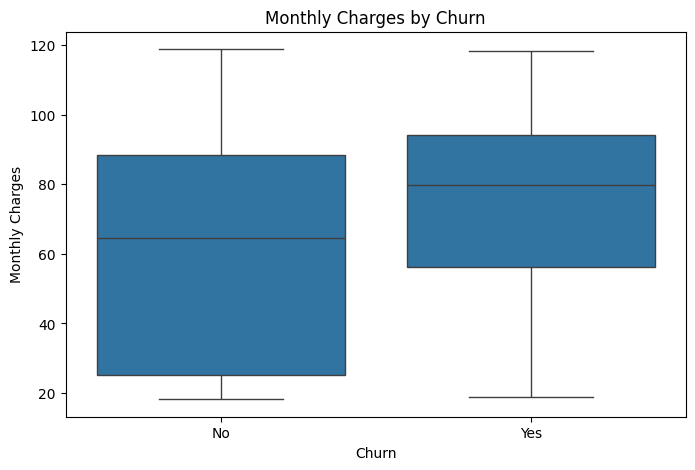

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

Customers who churn tend to have different monthly charge distributions compared with customers who remain.

### Insight

Monthly charges may be related to customer churn and could be useful for identifying higher-risk customer segments.

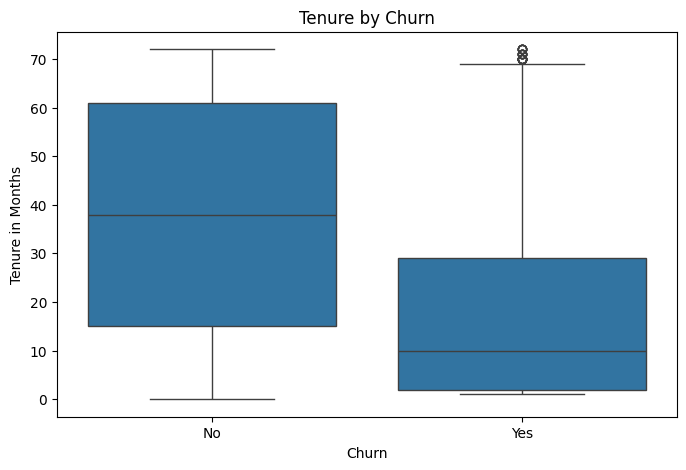

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure in Months")

plt.show()

### Observation

Customers who churn generally have shorter tenure than customers who remain.

### Insight

Newer customers appear to be a higher-risk group for churn.

This suggests that the early customer lifecycle may require additional retention attention.

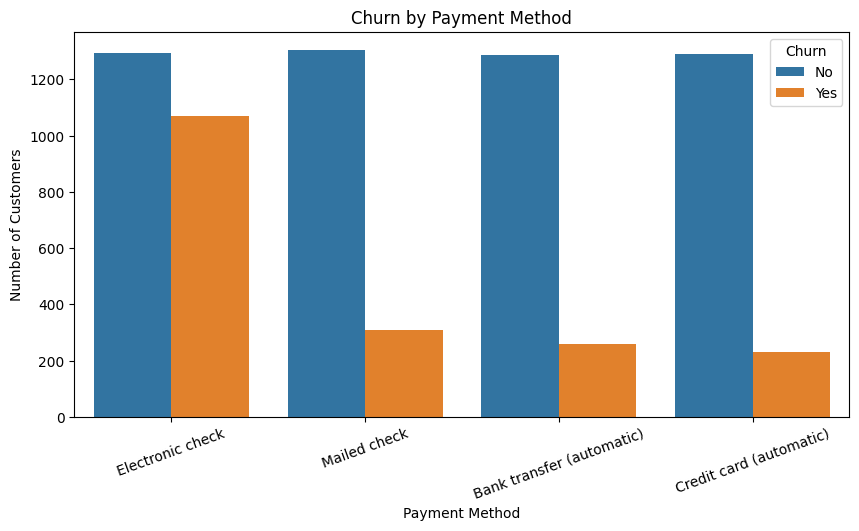

In [21]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Observation

Churn levels vary between payment methods.

### Insight

Payment method may help identify customer groups with different churn behavior.

Further investigation is required before concluding that payment method directly causes churn.

# 14. Important Patterns

The EDA reveals several important patterns:

1. Month-to-month customers show higher churn than customers with longer contracts.

2. Customers with shorter tenure appear more likely to churn.

3. Churn differs across internet service categories.

4. Monthly charges show different distributions between customers who churn and customers who stay.

5. Payment methods show differences in churn behavior.

6. Tenure and TotalCharges have a strong positive relationship.

7. MonthlyCharges and TotalCharges are also positively related.

# 15. Business Insights

### Insight 1 – Contract Type

Month-to-month customers represent an important churn-risk segment.

The company could focus retention efforts on these customers and encourage suitable customers to move toward longer-term contracts.

### Insight 2 – New Customers

Customers with shorter tenure appear more likely to churn.

The business could introduce stronger onboarding and early-stage customer engagement programs.

### Insight 3 – Internet Service

Churn behavior differs between internet service groups.

The company should investigate whether pricing, service quality, or customer experience contributes to these differences.

### Insight 4 – Monthly Charges

Customers with different monthly charge levels show different churn behavior.

Pricing and perceived value should therefore be investigated as possible factors affecting retention.

### Insight 5 – Payment Method

Different payment methods show different churn patterns.

The company could investigate whether payment experience or payment convenience contributes to customer retention.

# 16. Potential Data Problems

The EDA identified several issues that should be addressed during the preprocessing stage:

### 1. TotalCharges Data Type

`TotalCharges` is stored as an object instead of a numerical data type.

Some values contain blank spaces, which need to be investigated.

### 2. Missing Values

Blank values in `TotalCharges` need to be converted and investigated properly.

### 3. Customer ID

`customerID` is an identifier and is unlikely to provide useful predictive information.

### 4. Categorical Variables

Many features are categorical and will require encoding before machine learning.

### 5. Feature Scaling

Numerical variables have different ranges and may require scaling depending on the machine learning algorithm.

### 6. Potential Outliers

Potential outliers in numerical features should be investigated before deciding whether they should be retained or treated.

### 7. Class Imbalance

The Churn classes are not equally represented.

This should be considered during future model development.

# 17. Recommendations

Based on the EDA, the next preprocessing stage should consider:

1. Convert `TotalCharges` into a numerical data type.

2. Investigate and appropriately handle missing values in `TotalCharges`.

3. Decide whether `customerID` should be removed because it is an identifier.

4. Encode categorical variables.

5. Scale numerical variables where required.

6. Investigate potential outliers before deciding how to treat them.

7. Consider the imbalance in the Churn variable when preparing data for machine learning.

8. Validate the dataset again after preprocessing.

# 18. Final Conclusion

The Telco Customer Churn dataset contains useful customer, service, contract, and billing information for understanding customer retention.

The EDA identified several important patterns.

Month-to-month customers and customers with shorter tenure appear to represent higher-risk groups.

Churn behavior also differs across internet service types, payment methods, and monthly charge levels.

The analysis also identified data-quality issues, particularly with the `TotalCharges` column.

These findings provide a clear direction for the next preprocessing stage.

The next stage should focus on data-type correction, missing-value treatment, categorical encoding, possible scaling, outlier investigation, and preparation of the data for future machine learning.